# Application of Digital Signal Processing in Biomedical Signal Processing: ECG Analysis

**Mask variant 6:** duration **12 s**, sampling rate **500 Hz**, bandpass **1–50 Hz**.


In [1]:
# Required libraries
# pip install neurokit2 scipy matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import neurokit2 as nk


Optional: `pip install --upgrade neurokit2` if imports fail.


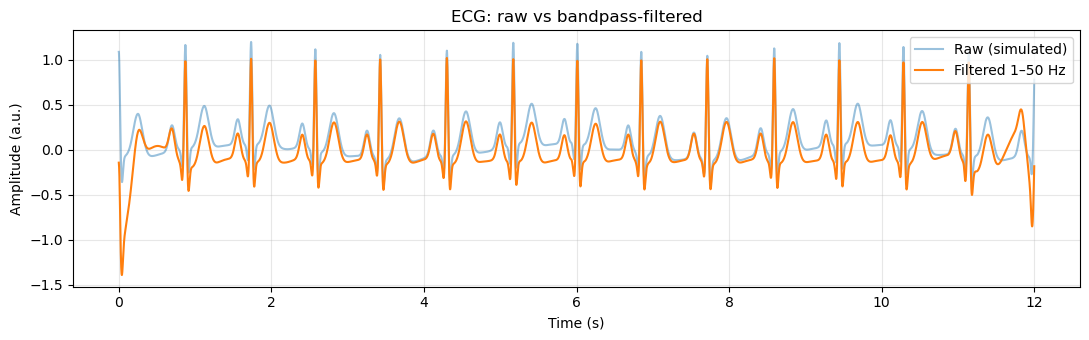

In [2]:
# 1) Load / simulate ECG (variant 6)
DURATION_S = 12
FS = 500  # Hz
LOW_HZ, HIGH_HZ = 1.0, 50.0  # bandpass cutoffs

np.random.seed(42)
ecg = nk.ecg_simulate(duration=DURATION_S, sampling_rate=FS, heart_rate=70, noise=0.01)
t = np.arange(len(ecg)) / FS


def bandpass_filter(signal, low_hz, high_hz, fs, order=4):
    """Zero-phase Butterworth bandpass (filtfilt)."""
    nyq = 0.5 * fs
    low = low_hz / nyq
    high = high_hz / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal)


# 2) Bandpass: removes baseline wander (below ~1 Hz) and HF noise (above 50 Hz)
filtered_ecg = bandpass_filter(ecg, LOW_HZ, HIGH_HZ, FS)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t, ecg, alpha=0.45, label="Raw (simulated)")
ax.plot(t, filtered_ecg, label=f"Filtered {LOW_HZ:.0f}–{HIGH_HZ:.0f} Hz")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (a.u.)")
ax.set_title("ECG: raw vs bandpass-filtered")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


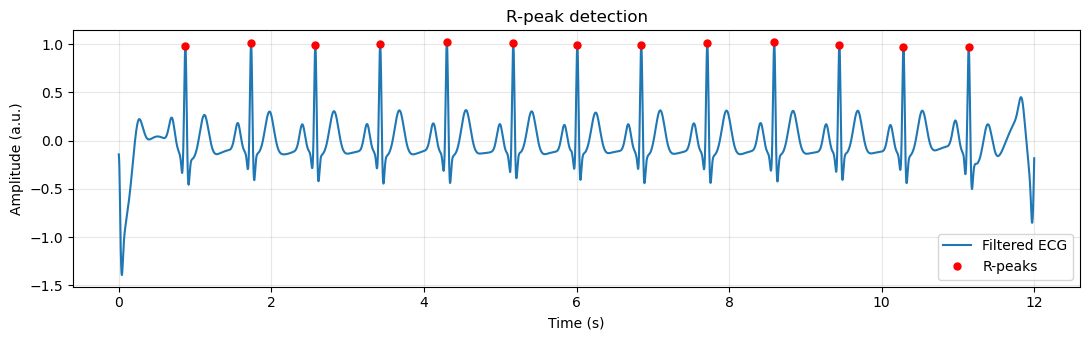

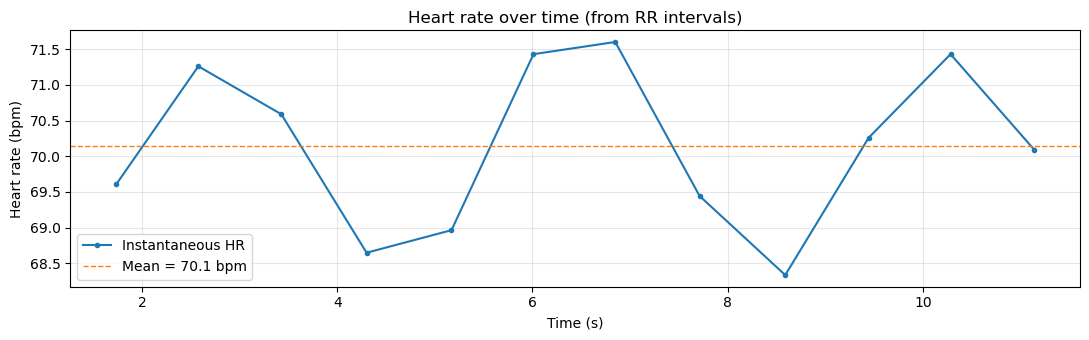

RR: mean=855.7 ms, std=13.5 ms
HR: mean=70.1 bpm, std=1.1 bpm, N beats=13


In [3]:
# 3) R-peak detection (neurokit2 pipeline on filtered signal)
signals, info = nk.ecg_process(filtered_ecg, sampling_rate=FS)
r_peaks = np.asarray(info["ECG_R_Peaks"], dtype=int)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t, filtered_ecg, label="Filtered ECG")
ax.plot(t[r_peaks], filtered_ecg[r_peaks], "ro", ms=5, label="R-peaks")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (a.u.)")
ax.set_title("R-peak detection")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Instantaneous heart rate from RR intervals (BPM)
if len(r_peaks) < 2:
    print("Not enough R-peaks for HR.")
else:
    rr_sec = np.diff(r_peaks) / FS
    hr_bpm = 60.0 / rr_sec
    # associate each HR sample with the end of its RR interval (second R)
    t_hr = t[r_peaks[1:]]

    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(t_hr, hr_bpm, "-o", ms=3, label="Instantaneous HR")
    ax.axhline(np.mean(hr_bpm), color="C1", ls="--", lw=1, label=f"Mean = {np.mean(hr_bpm):.1f} bpm")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Heart rate (bpm)")
    ax.set_title("Heart rate over time (from RR intervals)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"RR: mean={np.mean(rr_sec)*1000:.1f} ms, std={np.std(rr_sec)*1000:.1f} ms")
    print(f"HR: mean={np.mean(hr_bpm):.1f} bpm, std={np.std(hr_bpm):.1f} bpm, N beats={len(r_peaks)}")


### 5) Interpretation (signal quality and parameters)

- **Bandpass 1–50 Hz (variant 6):** The high-pass (~1 Hz) removes slow baseline drift and breathing-related wander so the QRS is not offset by a slowly moving baseline. The low-pass (~50 Hz) attenuates high-frequency interference (e.g. muscle EMG, sharp spikes) while preserving most QRS energy (commonly cited roughly ~5–40 Hz). These cutoffs match the filter specification for this lab variant.

- **Effect on R-peak detection:** NeuroKit2 uses morphology- and derivative-based steps; a stable baseline from the high-pass reduces spurious maxima from drift, and limiting HF noise reduces spikes that could be mistaken for R waves. In the figures above, the bandpassed QRS complexes look regular and the R markers align with sharp deflections, which supports consistent R timing. If the **low cut were too high** (e.g. much above ~1 Hz), P/T/ST waves would be distorted; if the **high cut were too low**, the QRS would smooth and the R instant could shift slightly.

- **This run (12 s at 500 Hz, simulated HR ~70 bpm, low additive noise):** The printed statistics (mean HR ≈70.1 bpm, SD ≈1.1 bpm; mean RR ≈856 ms, SD ≈13.5 ms; 13 R-peaks in 12 s) match the simulator settings and show a **smooth HR trace**, not a noisy one—the small beat-to-beat variation is what you expect from a clean simulation at this sampling rate. On **real** ECGs, stronger artifacts or electrode motion would more often produce spikes or gaps in the HR series unless further cleaning or stricter peak handling is applied.
